In [58]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df=pd.read_csv('/content/reviews_data.csv')
df

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...
...,...,...,...,...,...,...
845,Becky,"Agoura Hills, CA","Reviewed July 13, 2006",NaN,I ordered two venti frappacino's without whipp...,['No Images']
846,Bob,"Goodrich, MI","Reviewed Jan. 3, 2005",NaN,No Review Text,['No Images']
847,Erik,"Valley Village, CA","Reviewed Nov. 5, 2004",NaN,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...",['No Images']
848,Andrew,"Fallbrook, CA","Reviewed Oct. 20, 2004",NaN,No Review Text,['No Images']


In [59]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [60]:
#Removing the Numerical Values

df=df.drop(columns=['Rating','Image_Links','Date'])
df.head(5)

,name,location,Review
0,Helen,"Wichita Falls, TX",Amber and LaDonna at the Starbucks on Southwes...
1,Courtney,"Apopka, FL",** at the Starbucks by the fire station on 436...
2,Daynelle,"Cranberry Twp, PA",I just wanted to go out of my way to recognize...
3,Taylor,"Seattle, WA",Me and my friend were at Starbucks and my card...
4,Tenessa,"Gresham, OR",I’m on this kick of drinking 5 cups of warm wa...


In [61]:
# Convert 'Review' column to lowercase
df['Review_lower']=df['Review'].str.lower()

print("Original and Lowercase Reviews:")
display(df[['Review','Review_lower']].head())

Original and Lowercase Reviews:


,Review,Review_lower
0,Amber and LaDonna at the Starbucks on Southwes...,amber and ladonna at the starbucks on southwes...
1,** at the Starbucks by the fire station on 436...,** at the starbucks by the fire station on 436...
2,I just wanted to go out of my way to recognize...,i just wanted to go out of my way to recognize...
3,Me and my friend were at Starbucks and my card...,me and my friend were at starbucks and my card...
4,I’m on this kick of drinking 5 cups of warm wa...,i’m on this kick of drinking 5 cups of warm wa...


In [62]:
# Tokenize the 'Review_lower' column into words
df['Review_tokens'] = df['Review_lower'].apply(word_tokenize)

print("Tokens for the first 5 reviews:")
df['Review_tokens'].head()

Tokens for the first 5 reviews:


,Review_tokens
0,"[amber, and, ladonna, at, the, starbucks, on, ..."
1,"[*, *, at, the, starbucks, by, the, fire, stat..."
2,"[i, just, wanted, to, go, out, of, my, way, to..."
3,"[me, and, my, friend, were, at, starbucks, and..."
4,"[i, ’, m, on, this, kick, of, drinking, 5, cup..."


In [63]:
stop_words = set(stopwords.words('english'))

# Function to remove stopwords from a list of tokens
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['filtered_tokens'] = df['Review_tokens'].apply(remove_stopwords)

print("Original Tokens vs. Tokens After Stopword Removal (first 5 reviews):")
df[['Review_tokens','filtered_tokens']].head()

Original Tokens vs. Tokens After Stopword Removal (first 5 reviews):


,Review_tokens,filtered_tokens
0,"[amber, and, ladonna, at, the, starbucks, on, ...","[amber, ladonna, starbucks, southwest, parkway..."
1,"[*, *, at, the, starbucks, by, the, fire, stat...","[*, *, starbucks, fire, station, 436, altamont..."
2,"[i, just, wanted, to, go, out, of, my, way, to...","[wanted, go, way, recognize, starbucks, employ..."
3,"[me, and, my, friend, were, at, starbucks, and...","[friend, starbucks, card, ’, work, ., thankful..."
4,"[i, ’, m, on, this, kick, of, drinking, 5, cup...","[’, kick, drinking, 5, cups, warm, water, ., w..."


In [64]:
stemmer=PorterStemmer()

# Function to apply stemming to a list of tokens
def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemmed_tokens'] = df['Review_tokens'].apply(stem_text)

print("Stemmed Tokens (first 10 reviews):")
df['stemmed_tokens'].head(10)

Stemmed Tokens (first 10 reviews):


,stemmed_tokens
0,"[amber, and, ladonna, at, the, starbuck, on, s..."
1,"[*, *, at, the, starbuck, by, the, fire, stati..."
2,"[i, just, want, to, go, out, of, my, way, to, ..."
3,"[me, and, my, friend, were, at, starbuck, and,..."
4,"[i, ’, m, on, thi, kick, of, drink, 5, cup, of..."
5,"[we, had, to, correct, them, on, our, order, 3..."
6,"[i, have, tri, starbuck, sever, differ, time, ..."
7,"[starbuck, near, me, just, launch, new, fall, ..."
8,"[i, order, onlin, for, the, reisterstown, rd, ..."
9,"[staff, at, the, smyth, st., superstor, locat,..."


In [65]:
lemmatizer=WordNetLemmatizer()

# Function to apply lemmatization to a list of tokens
def lemmetize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_tokens'] = df['Review_tokens'].apply(lemmetize_text)

print("Comparison of Stemmed, and Lemmatized Tokens:")
df[['stemmed_tokens','lemmatized_tokens']].head()

Comparison of Stemmed, and Lemmatized Tokens:


,stemmed_tokens,lemmatized_tokens
0,"[amber, and, ladonna, at, the, starbuck, on, s...","[amber, and, ladonna, at, the, starbucks, on, ..."
1,"[*, *, at, the, starbuck, by, the, fire, stati...","[*, *, at, the, starbucks, by, the, fire, stat..."
2,"[i, just, want, to, go, out, of, my, way, to, ...","[i, just, wanted, to, go, out, of, my, way, to..."
3,"[me, and, my, friend, were, at, starbuck, and,...","[me, and, my, friend, were, at, starbucks, and..."
4,"[i, ’, m, on, thi, kick, of, drink, 5, cup, of...","[i, ’, m, on, this, kick, of, drinking, 5, cup..."


In [74]:
bow_vectorizer=CountVectorizer()
bow_matrix=bow_vectorizer.fit_transform(df['Review'])

bow_df=pd.DataFrame(bow_matrix.toarray(),columns=bow_vectorizer.get_feature_names_out())


print("Vocabulary (first 20):")
print(list(bow_vectorizer.vocabulary_.items())[:20])


#Display bag of words representation
print("\nBag of Words Representation:")
print(bow_df)

print("\nShape of the matrix")
print(bow_df.shape)

Vocabulary (first 20):
[('amber', 466), ('and', 484), ('ladonna', 3005), ('at', 599), ('the', 5293), ('starbucks', 5004), ('on', 3674), ('southwest', 4923), ('parkway', 3804), ('are', 550), ('always', 461), ('so', 4877), ('warm', 5761), ('welcoming', 5816), ('there', 5303), ('is', 2880), ('smile', 4848), ('in', 2749), ('their', 5296), ('voice', 5719)]

Bag of Words Representation:
     00  000  000php  00am  01  02  02239  0266  03  04  ...  youth  youtube  \
0     0    0       0     0   0   0      0     0   0   0  ...      0        0   
1     0    0       0     0   0   0      0     0   0   0  ...      0        0   
2     0    0       0     0   0   0      0     0   0   0  ...      0        0   
3     0    0       0     0   0   0      0     0   0   0  ...      0        0   
4     0    0       0     0   0   0      0     0   0   0  ...      0        0   
..   ..  ...     ...   ...  ..  ..    ...   ...  ..  ..  ...    ...      ...   
845   0    0       0     0   0   0      0     0   0   0 

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

df['Review_processed'] = df['lemmatized_tokens'].apply(lambda tokens: ' '.join(tokens))

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the processed reviews
X_tfidf = tfidf_vectorizer.fit_transform(df['Review_processed'])

# Display vocabulary
print("\nTF-IDF Vocabulary (first 20):")
print(list(tfidf_vectorizer.vocabulary_.items())[:20])

# Display feature names (words in the vocabulary)
print("\nTF-IDF Feature Names (Top 20):")
print(tfidf_vectorizer.get_feature_names_out()[:20])

# Display the TF-IDF document-term matrix (first 5 rows, first 10 columns)
print("\nTF-IDF Document-Term Matrix (first 5 rows, first 10 columns):")
print(X_tfidf.toarray())

# Display the shape of the TF-IDF document-term matrix
print("\nShape of the TF-IDF Document-Term Matrix:")
print(X_tfidf.shape)


TF-IDF Vocabulary (first 20):
[('amber', 457), ('and', 473), ('ladonna', 2777), ('at', 583), ('the', 4848), ('starbucks', 4589), ('on', 3376), ('southwest', 4514), ('parkway', 3494), ('are', 536), ('always', 452), ('so', 4470), ('warm', 5282), ('welcoming', 5330), ('there', 4858), ('is', 2665), ('smile', 4444), ('in', 2539), ('their', 4851), ('voice', 5245)]

TF-IDF Feature Names (Top 20):
['00' '000' '000php' '00am' '01' '02' '02239' '0266' '03' '04' '0403907'
 '05' '06' '06486' '07' '08' '09' '10' '100' '1000']

TF-IDF Document-Term Matrix (first 5 rows, first 10 columns):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Shape of the TF-IDF Document-Term Matrix:
(850, 5477)


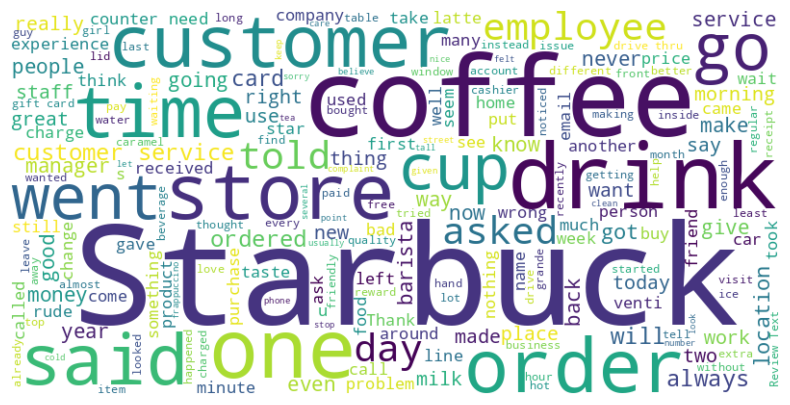

In [68]:
# Concatenate all processed reviews into a single string
all_words=' '.join(df['Review'])

# Generate a Word Cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()